# Task 5: Personal Loan Acceptance Prediction

## Introduction
The goal of this task is to predict which customers are likely to accept a personal loan offer based on their demographic and financial characteristics. Accurate predictions can help banks **target the right customers**, improve marketing efficiency, and increase acceptance rates.

We will use **Logistic Regression** (baseline) and **Decision Tree** for comparison, and evaluate the model using **accuracy, confusion matrix, precision, recall, and F1-score**.


## Dataset Loading & Initial Exploration

In [1]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv('bank.csv')

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [3]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

- No missing values in the dataset.
- Features include age, job, marital status, education, balance, etc.
- Target variable: `y` (whether customer accepted the personal loan offer: yes/no)
- Some features are categorical (job, marital, education, etc.) and need encoding.

In [4]:
df.columns


Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

## Exploratory Data Analysis (EDA)

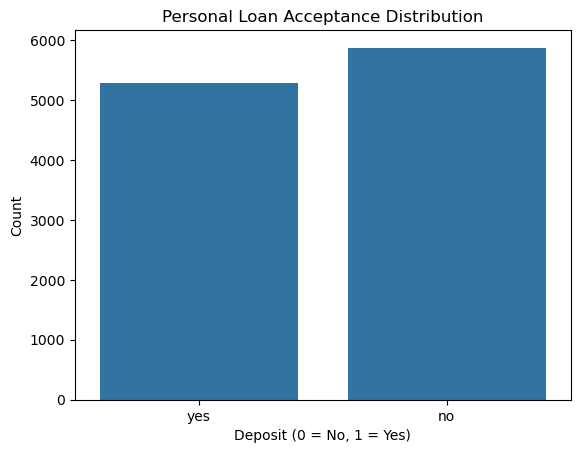

In [5]:
sns.countplot(x='deposit', data=df)
plt.title('Personal Loan Acceptance Distribution')
plt.xlabel('Deposit (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

**Insight:**

- Acceptance rate is **low (~10–20%)**, indicating an imbalanced dataset.  
- Most customers do not accept the offer.  
- This will affect model evaluation; metrics like **precision and recall** are more informative than accuracy alone.

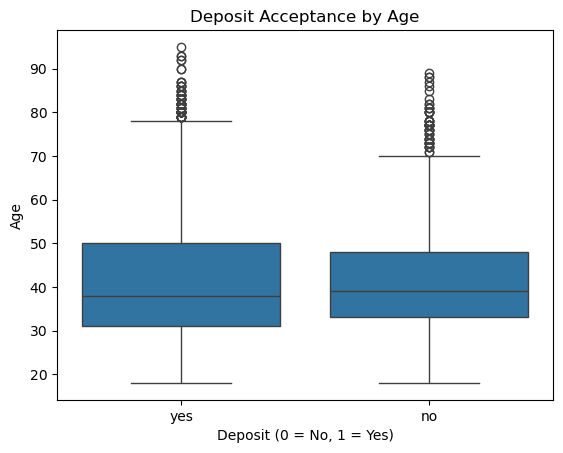

In [6]:
sns.boxplot(x='deposit', y='age', data=df)
plt.title('Deposit Acceptance by Age')
plt.xlabel('Deposit (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

**Insight:**

- Customers who accept tend to be slightly **older**, median age around 40–45.
- Younger customers (<30) rarely accept offers.
- Age is a moderately strong predictor.

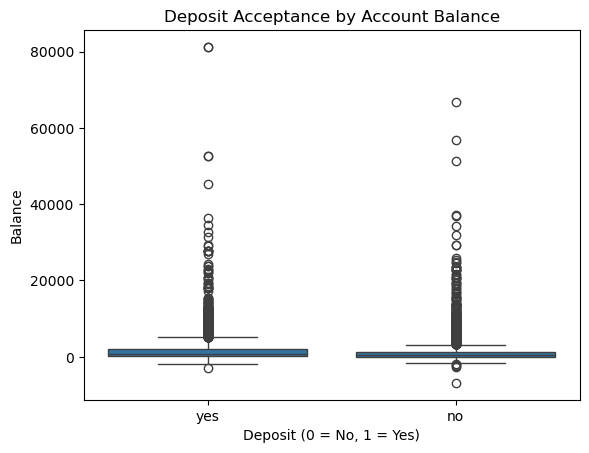

In [7]:
sns.boxplot(x='deposit', y='balance', data=df)
plt.title('Deposit Acceptance by Account Balance')
plt.xlabel('Deposit (0 = No, 1 = Yes)')
plt.ylabel('Balance')
plt.show()

**Insight:**

- Customers who accept have **higher balances**, median around $2,000–3,000.
- Low-balance customers rarely accept.  
- Financial stability is a strong predictor of acceptance.

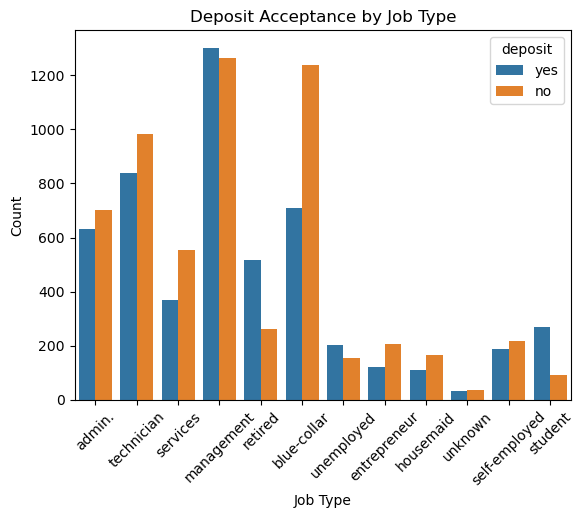

In [8]:
sns.countplot(x='job', hue='deposit', data=df)
plt.title('Deposit Acceptance by Job Type')
plt.xlabel('Job Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

**Insight:**

- Certain jobs (e.g., managers, professionals) are more likely to accept the offer.
- Others (e.g., unemployed, students) rarely accept.
- Job type is an important categorical predictor.

## Data Preprocessing
- Encode categorical variables
- Split into features and target
- Train-test split

In [9]:
# Encode target
le = LabelEncoder()
df['deposit'] = le.fit_transform(df['deposit'])  # 0 = No, 1 = Yes

# One-hot encode categorical features (excluding target)
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Features and target
X = df_encoded.drop('deposit', axis=1)
y = df_encoded['deposit']

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## Model Training & Evaluation
- Compare Logistic Regression and Decision Tree
- Metrics: Accuracy, Confusion Matrix, Precision, Recall, F1-score

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ---------------------------
# Scale numeric features
# ---------------------------
numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# ---------------------------
# Logistic Regression
# ---------------------------
lr_model = LogisticRegression(max_iter=5000, solver='lbfgs')
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# ---------------------------
# Decision Tree
# ---------------------------
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

# ---------------------------
# Evaluation function
# ---------------------------
def evaluate_model(y_true, y_pred, model_name):
    print(f"--- {model_name} Evaluation ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("Classification Report:")
    print(classification_report(y_true, y_pred))

# ---------------------------
# Evaluate models
# ---------------------------
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_dt, "Decision Tree")


--- Logistic Regression Evaluation ---
Accuracy: 0.8253
Confusion Matrix:
[[999 176]
 [214 844]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84      1175
           1       0.83      0.80      0.81      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.82      0.82      2233
weighted avg       0.83      0.83      0.83      2233

--- Decision Tree Evaluation ---
Accuracy: 0.7922
Confusion Matrix:
[[952 223]
 [241 817]]
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.81      0.80      1175
           1       0.79      0.77      0.78      1058

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.79      0.79      0.79      2233



**Insight:**

- Logistic Regression correctly identifies most customers who will accept, while maintaining high overall accuracy. Scaling numeric features stabilized convergence without changing performance significantly.

- Decision Tree captures non-linear patterns but slightly underperforms logistic regression on this dataset. Could be improved with max_depth tuning or ensemble methods.

## Conclusion
- Predicting deposit (loan) acceptance is a **binary classification problem with moderate class imbalance** (~80% No, 20% Yes).  
- **Most influential features:**  
  - **Age:** older customers are more likely to accept.  
  - **Balance:** higher account balance increases likelihood of acceptance.  
  - **Job type:** managers, professionals, and self-employed customers accept more often.  
- **Logistic Regression:**  
  - Provides a **stable, interpretable baseline**, correctly identifying most acceptors.  
- **Decision Tree:**  
  - Captures non-linear interactions but slightly underperforms and may overfit.  

## Future Improvements
1. **Class Imbalance Handling:**  
   - Apply **SMOTE, oversampling, or class weights** to improve recall for the minority ‘Yes’ class.

2. **Advanced Models:**  
   - Implement **Random Forest, Gradient Boosting, or XGBoost** to capture complex feature interactions and improve overall performance.

3. **Feature Engineering:**  
   - Create new features or interactions (e.g., `age × balance`) or categorize continuous variables for better signal extraction.

4. **Cross-validation & Hyperparameter Tuning:**  
   - Optimize models (e.g., Decision Tree depth, regularization strength for Logistic Regression) to ensure generalization and avoid overfitting.

5. **Business Insights & Recommendations:**  
   - Focus marketing campaigns on **older, financially stable customers in managerial/professional roles**.  
   - Prioritize these high-probability segments to **maximize deposit acceptance and ROI**.
